#  Notebook 05 — Product & Category Analysis
## Goal: Identify best and worst performing product categories
**Business Value:** Drive investment decisions, identify quality issues, optimize product mix
**Tools:** Python, Pandas, Matplotlib, Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

master = pd.read_csv("../data/processed/master_clean.csv")

master['order_purchase_timestamp'] = pd.to_datetime(
    master['order_purchase_timestamp'], errors='coerce'
)

print(" Data loaded!")
print(f" Shape: {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f" Unique categories: {master['product_category_name_english'].nunique()}")

 Data loaded!
 Shape: 119,143 rows × 28 columns
 Unique categories: 72


## Question 1 — Top 10 Categories by Revenue

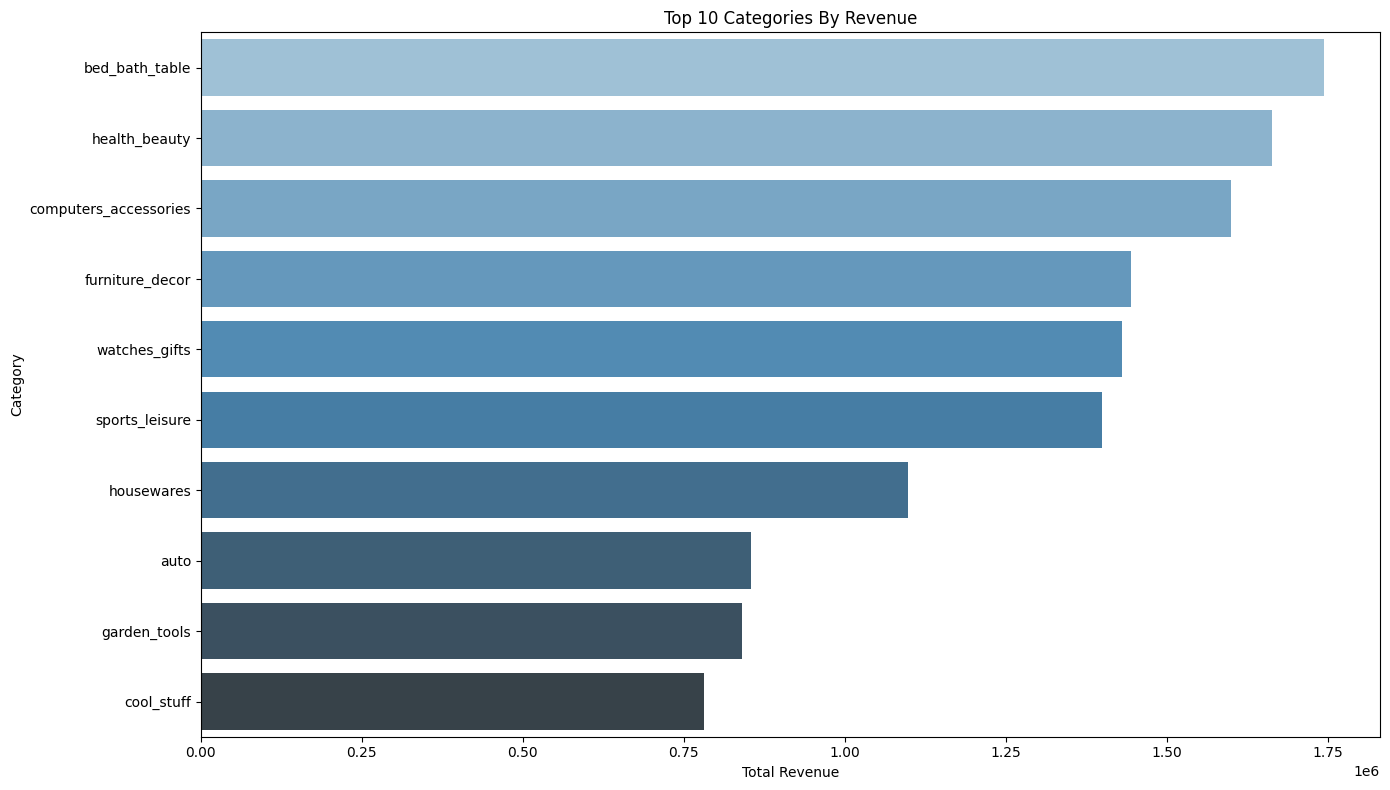

TOP 10 CATEGORIES BY REVENUE:
 bed_bath_table                      -> R$ 1,743,999
 health_beauty                       -> R$ 1,662,964
 computers_accessories               -> R$ 1,599,481
 furniture_decor                     -> R$ 1,443,964
 watches_gifts                       -> R$ 1,430,553
 sports_leisure                      -> R$ 1,400,223
 housewares                          -> R$ 1,097,900
 auto                                -> R$ 855,096
 garden_tools                        -> R$ 840,722
 cool_stuff                          -> R$ 781,934


In [2]:
category_revenue =master.groupby('product_category_name_english')['payment_value'].sum().reset_index()
category_revenue.columns=['category','revenue']
category_revenue= category_revenue.sort_values('revenue',ascending=False)

top10_revenue = category_revenue.head(10)

plt.figure(figsize=(14,8))
sns.barplot(data=top10_revenue,y='category',x='revenue', palette='Blues_d')
plt.title('Top 10 Categories By Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('../visuals/18_top_categories_revenue.png',dpi=150)
plt.show()

print("TOP 10 CATEGORIES BY REVENUE:")
for _,row in top10_revenue.iterrows():
    print(f" {row['category']:35s} -> R$ {row['revenue']:,.0f}")

## Question 2 Top 10 Categories by Order Volume

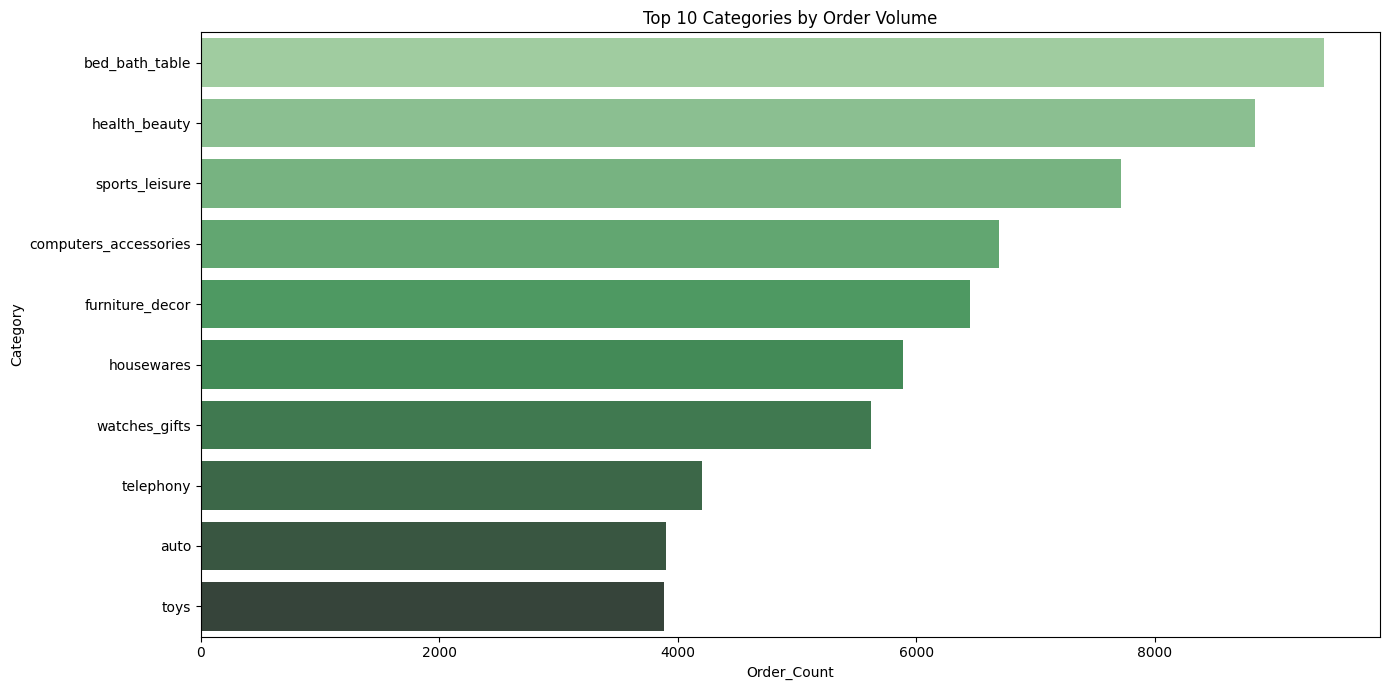

 
 Top 10 Categories by Orders:
 bed_bath_table                      -> 9,417
 health_beauty                       -> 8,836
 sports_leisure                      -> 7,720
 computers_accessories               -> 6,689
 furniture_decor                     -> 6,449
 housewares                          -> 5,884
 watches_gifts                       -> 5,624
 telephony                           -> 4,199
 auto                                -> 3,897
 toys                                -> 3,886

 KEY INSIGHT - Revenue rank vs Order rank:
 Top 5 by Revenue: ['bed_bath_table', 'health_beauty', 'computers_accessories', 'furniture_decor', 'watches_gifts']
 Top 5 by Orders: ['bed_bath_table', 'health_beauty', 'computers_accessories', 'furniture_decor', 'watches_gifts']


In [3]:
category_orders = master.groupby('product_category_name_english')['order_id'].nunique().reset_index()
category_orders.columns =['category','order_count']
category_orders =category_orders.sort_values('order_count',ascending=False)

top10_category =category_orders.head(10)

plt.figure(figsize=(14,7))
sns.barplot(data=top10_category, y='category',x='order_count',palette='Greens_d')
plt.title('Top 10 Categories by Order Volume')
plt.xlabel('Order_Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('../visuals/19_Categories_orders.png',dpi=150)
plt.show()

print(" \n Top 10 Categories by Orders:")
for _, row in top10_category.iterrows():
    print(f" {row['category']:35s} -> {row['order_count']:,}")


print("\n KEY INSIGHT - Revenue rank vs Order rank:")
top5_rev = category_revenue.head(5)['category'].tolist()
top5_ord = category_revenue.head(5)['category'].tolist()
print(f" Top 5 by Revenue: {top5_rev}")
print(f" Top 5 by Orders: {top5_ord}")
    


##  Question 3  Average Review Score by Category

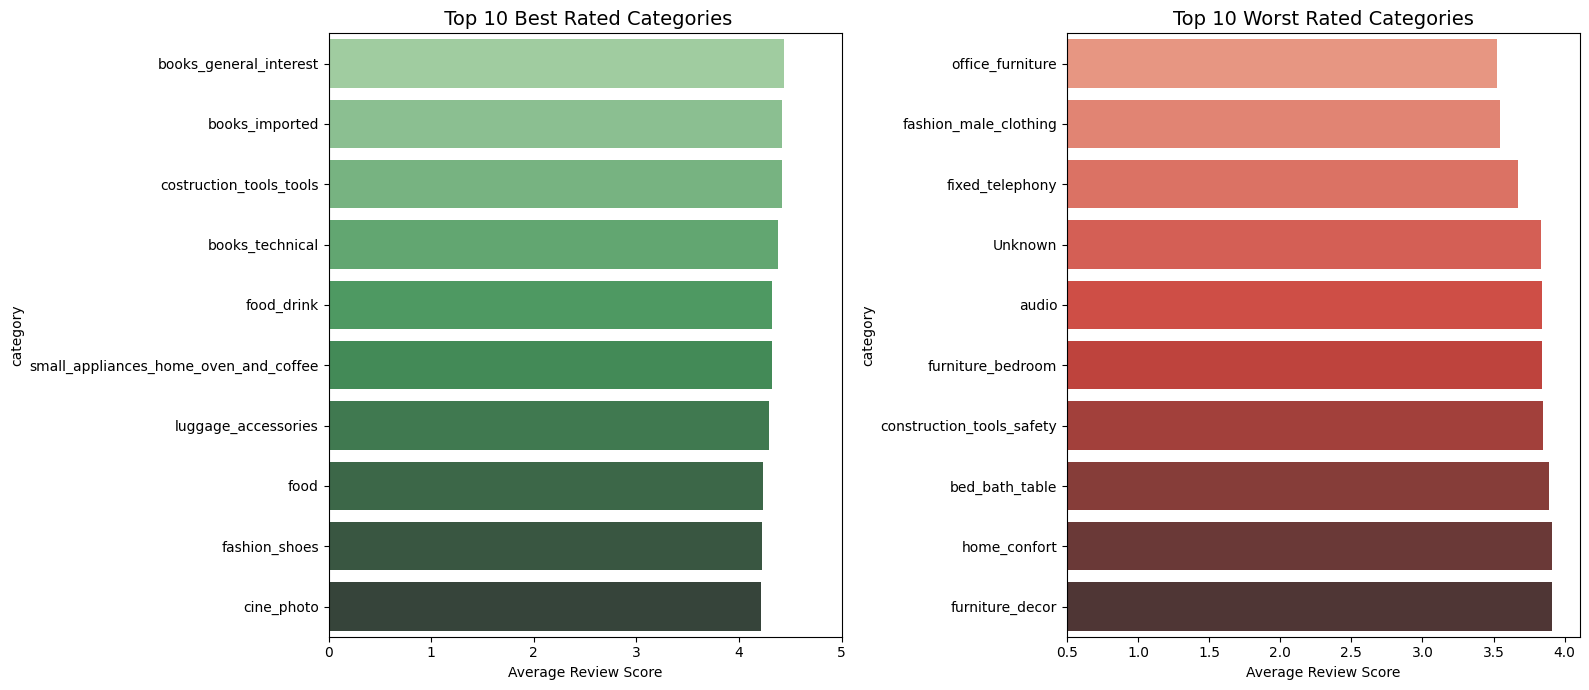

 Best Rated: books_general_interest (4.44)
 Worst Rated: office_furniture (3.53)


In [4]:
category_reviews = master.groupby('product_category_name_english')['review_score'].mean().reset_index()
category_reviews.columns=['category','avg_review']

category_order_counts = master.groupby('product_category_name_english')['order_id'].nunique().reset_index()
category_order_counts.columns=['category','order_count']

category_reviews = category_reviews.merge(category_order_counts, on='category')
category_reviews = category_reviews[category_reviews['order_count']>=50]

best_rated = category_reviews.sort_values('avg_review',ascending=False).head(10)
worst_rated = category_reviews.sort_values('avg_review',ascending=True).head(10)

fig, axes = plt.subplots(1,2, figsize=(16,7))
sns.barplot(data=best_rated, y='category', x='avg_review', palette='Greens_d', ax=axes[0])
axes[0].set_title(' Top 10 Best Rated Categories', fontsize=14)
axes[0].set_xlabel('Average Review Score')
axes[0].set_xlim(0,5)

sns.barplot(data=worst_rated, y='category', x='avg_review', palette='Reds_d', ax=axes[1])
axes[1].set_title('Top 10 Worst Rated Categories', fontsize=14)
axes[1].set_xlabel('Average Review Score')
axes[1].set_xlim(0.5)

plt.tight_layout()
plt.savefig('../visuals/20_category_reviews.png', dpi=150)
plt.show()


print(f" Best Rated: {best_rated.iloc[0]['category']} ({best_rated.iloc[0]['avg_review']:,.2f})")
print(f" Worst Rated: {worst_rated.iloc[0]['category']} ({worst_rated.iloc[0]['avg_review']:.2f})")


##  Question 4  Revenue vs Review Score (Are expensive products well rated?)

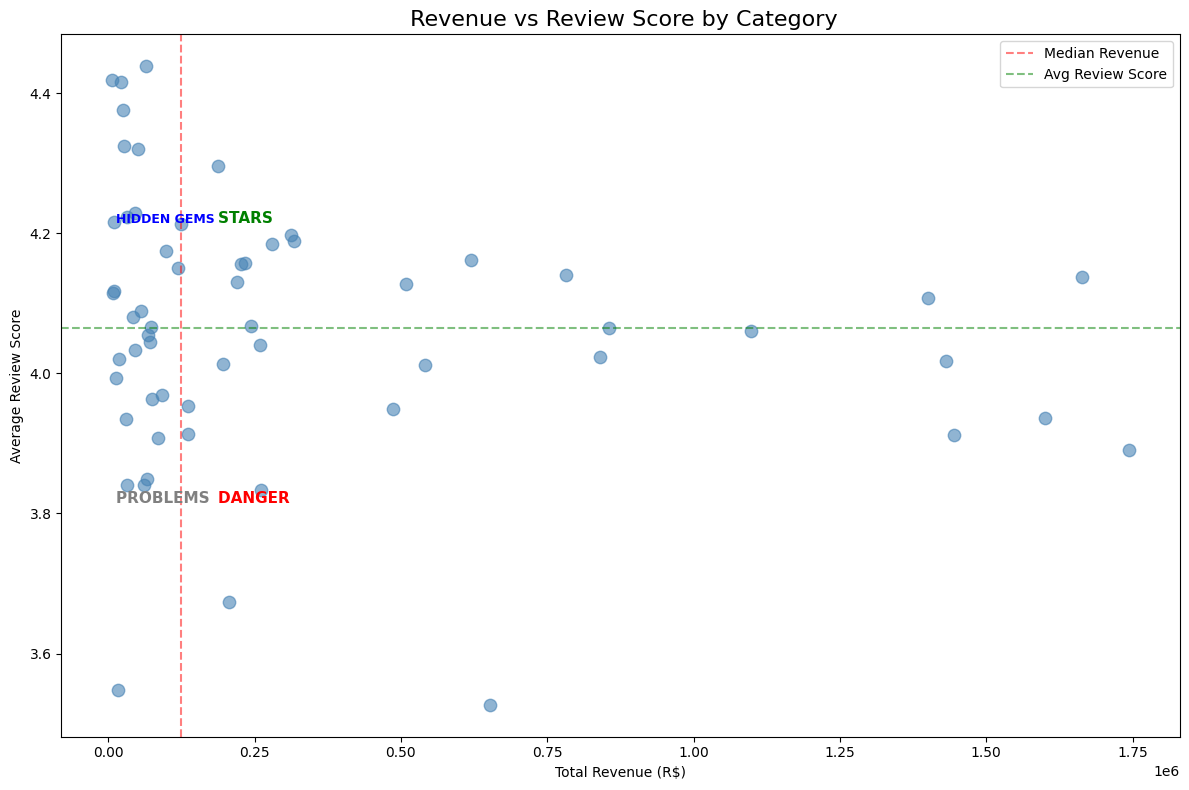

In [5]:

category_summary = category_revenue.merge(category_reviews, on='category')

median_revenue = category_summary['revenue'].median()
avg_score = category_summary['avg_review'].mean()

plt.figure(figsize=(12, 8))
plt.scatter(category_summary['revenue'],
            category_summary['avg_review'],
            alpha=0.6, color='steelblue', s=80)

# Dividing lines to create 4 quadrants
plt.axvline(x=median_revenue, color='red',
            linestyle='--', alpha=0.5, label='Median Revenue')
plt.axhline(y=avg_score, color='green',
            linestyle='--', alpha=0.5, label='Avg Review Score')

# Add quadrant labels
plt.text(median_revenue * 1.5, avg_score + 0.15,
         'STARS ', fontsize=11, color='green', fontweight='bold')
plt.text(median_revenue * 1.5, avg_score - 0.25,
         'DANGER ', fontsize=11, color='red', fontweight='bold')
plt.text(median_revenue * 0.1, avg_score + 0.15,
         'HIDDEN GEMS ', fontsize=9, color='blue', fontweight='bold')
plt.text(median_revenue * 0.1, avg_score - 0.25,
         'PROBLEMS ', fontsize=11, color='grey', fontweight='bold')

plt.title(' Revenue vs Review Score by Category', fontsize=16)
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Average Review Score')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/21_revenue_vs_review.png', dpi=150)
plt.show()

##  Question 5  Product Weight vs Freight Cost

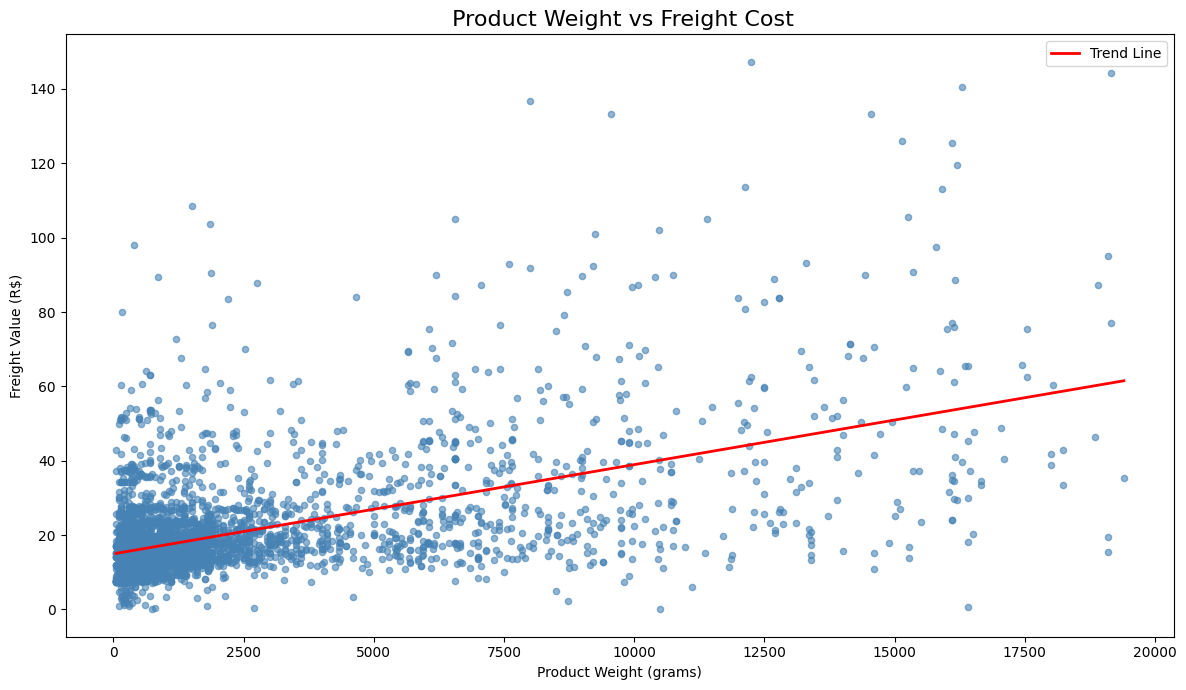

 Correlation between freight and weight : 0.558
 Interpretation : Moderate relationship — weight partially drives freight cost


In [6]:
weight_freight = master[
    (master['product_weight_g']>0) &
    (master['product_weight_g']<20000)&
    (master['freight_value'] > 0) &
    (master['freight_value'] <150)].copy()

sample = weight_freight.sample(5000, random_state=42)

plt.figure(figsize=(12,7))
plt.scatter(sample['product_weight_g'], sample['freight_value'],
            alpha=0.6, color='steelblue', s=20)

z=np.polyfit(sample['product_weight_g'], sample['freight_value'],1)
p = np.poly1d(z)
plt.plot(sorted(sample['product_weight_g']),
         p(sorted(sample['product_weight_g'])),
         color='red', linewidth=2, label='Trend Line')

plt.title(' Product Weight vs Freight Cost', fontsize=16)
plt.xlabel('Product Weight (grams)')
plt.ylabel('Freight Value (R$)')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/22_weight_freight.png', dpi=150)
plt.show()

correlation = np.corrcoef(sample['product_weight_g'],
                          sample['freight_value'])[0][1]
print(f" Correlation between freight and weight : {correlation:.3f}")
print(f" Interpretation : ", end="")
if correlation > 0.7:
    print("Strong positive relationship — heavier = significantly more expensive")
elif correlation > 0.4:
    print("Moderate relationship — weight partially drives freight cost")
else:
    print("Weak relationship — other factors drive freight cost more than weight")

## Question 6 Category Performance Matrix

In [7]:
master['freight_pct']=master['freight_value']/(master['price'] + master['freight_value']) * 100

scorecard= master.groupby('product_category_name_english').agg(
    Revenue = ('payment_value','sum'),
    Orders = ('order_id','nunique'),
    Avg_Price = ('price','mean'),
    Avg_review =('review_score','mean'),
    Avg_Freight_pct = ('freight_pct','mean')
).reset_index()

scorecard.columns=['Category','Revenue','Orders','Avg_Price','Avg_Review','Avg_freight_Pct']

scorecard= scorecard[scorecard['Orders'] >=50]
scorecard= scorecard.sort_values('Revenue', ascending=False)

scorecard['Revenue']= scorecard['Revenue'].round(0)
scorecard['Avg_Price'] = scorecard['Avg_Price'].round(2)
scorecard['Avg_Review'] = scorecard['Avg_Review'].round(2)
scorecard['Avg_Freight_Pct'] = scorecard['Avg_freight_Pct'].round(1)

print(" CATEGORY PERFORMANCE SCOREBOARD - TOP 15")
print("=" * 90)
print(scorecard.head(15).to_string(index=False))
print("=" * 90)


 CATEGORY PERFORMANCE SCOREBOARD - TOP 15
             Category   Revenue  Orders  Avg_Price  Avg_Review  Avg_freight_Pct  Avg_Freight_Pct
       bed_bath_table 1743999.0    9417      92.36        3.89        20.470099             20.5
        health_beauty 1662964.0    8836     129.78        4.14        19.956422             20.0
computers_accessories 1599481.0    6689     116.57        3.94        20.493216             20.5
      furniture_decor 1443964.0    6449      87.42        3.91        23.286709             23.3
        watches_gifts 1430553.0    5624     201.89        4.02        13.236664             13.2
       sports_leisure 1400223.0    7720     114.35        4.11        20.398410             20.4
           housewares 1097900.0    5884      90.63        4.06        25.170998             25.2
                 auto  855096.0    3897     140.54        4.06        21.447330             21.4
         garden_tools  840722.0    3518     113.18        4.02        23.034400      

## Question 7 Business Recommendations

In [8]:

# Find star category — top revenue + good reviews
stars = scorecard[scorecard['Avg_Review'] >= 4.0].head(1)
star_cat = stars.iloc[0]['Category']
star_rev = stars.iloc[0]['Revenue']

# Find danger category — top revenue + bad reviews
danger = scorecard[scorecard['Avg_Review'] < 3.8].head(1)
danger_cat = danger.iloc[0]['Category'] if len(danger) > 0 else 'N/A'

# Find highest freight burden category
high_freight = scorecard.sort_values('Avg_Freight_Pct', ascending=False).iloc[0]

# Find hidden gem — good reviews but lower revenue
gems = scorecard[
    (scorecard['Avg_Review'] >= 4.2) &
    (scorecard['Revenue'] < scorecard['Revenue'].median())
].head(1)
gem_cat = gems.iloc[0]['Category'] if len(gems) > 0 else 'N/A'

print("=" * 60)
print("   PRODUCT ANALYSIS — BUSINESS RECOMMENDATIONS")
print("=" * 60)
print(f"""
 STAR CATEGORY — {star_cat}
   Revenue: R$ {star_rev:,.0f} with strong customer satisfaction
   → Double down — increase inventory and marketing spend
   → Negotiate better supplier deals given high volume
   → Use as anchor category for cross-selling

    DANGER CATEGORY — {danger_cat}
     → High revenue but below average customer satisfaction
   → Investigate root cause — product quality or delivery?
   → If quality issue — work with suppliers immediately
   → Risk: unhappy customers don't return = future revenue loss

     HIDDEN GEM — {gem_cat}
   → Excellent reviews but low revenue = underexposed
   → Increase visibility through promotions and ads
   → Consider bundling with top categories to drive discovery

     FREIGHT CONCERN — {high_freight['Category']}
   → Average freight is {high_freight['Avg_Freight_Pct']:.1f}% of order value
   → Customers paying this much for delivery will look elsewhere
   → Consider free shipping threshold or seller-side logistics support

     OVERALL RECOMMENDATION:
   → Focus retention budget on Star categories
   → Fix quality issues in Danger categories before they erode revenue
   → Promote Hidden Gems to diversify revenue sources
   → Reduce freight burden in heavy categories through logistics deals
""")
print("=" * 60)

   PRODUCT ANALYSIS — BUSINESS RECOMMENDATIONS

 STAR CATEGORY — health_beauty
   Revenue: R$ 1,662,964 with strong customer satisfaction
   → Double down — increase inventory and marketing spend
   → Negotiate better supplier deals given high volume
   → Use as anchor category for cross-selling

    DANGER CATEGORY — office_furniture
     → High revenue but below average customer satisfaction
   → Investigate root cause — product quality or delivery?
   → If quality issue — work with suppliers immediately
   → Risk: unhappy customers don't return = future revenue loss

     HIDDEN GEM — books_general_interest
   → Excellent reviews but low revenue = underexposed
   → Increase visibility through promotions and ads
   → Consider bundling with top categories to drive discovery

     FREIGHT CONCERN — dvds_blu_ray
   → Average freight is 39.2% of order value
   → Customers paying this much for delivery will look elsewhere
   → Consider free shipping threshold or seller-side logistics supp